# Etape 3 - Analyse non supervisee

**Projet BrainScanAI** - Detection de tumeurs cerebrales  
Objectif : reduire la dimensionnalite des features (PCA, UMAP, t-SNE), appliquer des algorithmes de clustering (K-Means, DBSCAN) et evaluer les regroupements avec le score ARI.

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Ajoute la racine du projet au chemin Python pour importer src/
sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reduction de dimensionnalite
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Evaluation
from sklearn.metrics import adjusted_rand_score, silhouette_score

print("Imports OK")

Imports OK


## 2. Configuration

In [2]:
# Importation des chemins et constantes depuis src/config.py
from src.config import PROCESSED_DIR, FEATURES_DIR, RESULTS_DIR, N_CLUSTERS, RANDOM_STATE

print(f"Features chargees depuis : {FEATURES_DIR}")
print(f"Donnees derivees sauvegardees dans : {PROCESSED_DIR}")
print(f"Resultats visuels sauvegardes dans : {RESULTS_DIR}")
print(f"Nombre de clusters cible : {N_CLUSTERS}")
print(f"Graine aleatoire : {RANDOM_STATE}")

Features chargees depuis : C:\Users\fkhellad\Formation_IA\Projet7_mission\data\processed\features
Donnees derivees sauvegardees dans : C:\Users\fkhellad\Formation_IA\Projet7_mission\data\processed
Resultats visuels sauvegardes dans : C:\Users\fkhellad\Formation_IA\Projet7_mission\results
Nombre de clusters cible : 2
Graine aleatoire : 42


## 3. Chargement des features produites a l'etape 2

In [3]:
# Charger la matrice de features ResNet50 : shape (1506, 2048)
features = np.load(FEATURES_DIR / "resnet50_features.npy")

# Charger les metadonnees associees (path, label, split)
meta = pd.read_csv(FEATURES_DIR / "resnet50_metadata.csv")

print(f"Matrice de features : {features.shape}")
print(f"  {features.shape[0]} images x {features.shape[1]} features")
print(f"\nDistribution des labels :")
print(meta["label"].value_counts(dropna=False))

# Masques de base : images labelisees vs sans label
labeled_mask   = meta["split"] == "labeled"    # 100 images avec label connu
unlabeled_mask = meta["split"] == "unlabeled"  # 1406 images sans label

Matrice de features : (1506, 2048)
  1506 images x 2048 features

Distribution des labels :
label
NaN       1406
cancer      50
normal      50
Name: count, dtype: int64


### Separation train / test sur les 100 images labelisees 
Le modele ne verra jamais ces images pendant l'entrainement ni le clustering

20% stratifie = 20 images (10 cancer + 10 normal) -- meme proportion dans chaque split

In [4]:
labeled_indices = np.where(labeled_mask)[0]

# Chargement du test set défini à l'étape 2 -- split effectué avant toute augmentation
test_paths_set = set(pd.read_csv(PROCESSED_DIR / "test_set.csv")["path"].values)

train_labeled_mask = np.zeros(len(meta), dtype=bool)
test_labeled_mask  = np.zeros(len(meta), dtype=bool)

for i in labeled_indices:
    if meta.loc[i, "path"] in test_paths_set:
        test_labeled_mask[i] = True
    else:
        train_labeled_mask[i] = True

meta_labeled = meta[train_labeled_mask].reset_index(drop=True)

print(f"Images labelisées total    : {labeled_mask.sum()}")
print(f"  Train labelisé           : {train_labeled_mask.sum()}  (clustering + ARI)")
print(f"  Test (mis de côté)       : {test_labeled_mask.sum()}  (étape 4 uniquement)")
print(f"Images sans label          : {unlabeled_mask.sum()}")
print(f"\nDistribution test set :")
print(meta[test_labeled_mask]["label"].value_counts())

Images labelisées total    : 100
  Train labelisé           : 80  (clustering + ARI)
  Test (mis de côté)       : 20  (étape 4 uniquement)
Images sans label          : 1406

Distribution test set :
label
cancer    10
normal    10
Name: count, dtype: int64


## 4. Standardisation des features

centrer et reduir chaque feature (colonne) pour qu'elle ait une moyenne de 0 et un ecart-type de 1.  
Le scaler est entrainé **sans les 20 images de test** pour eviter tout leakage de distribution.

In [5]:
train_mask = ~test_labeled_mask  # True pour les 1486 images non-test

scaler = StandardScaler()
scaler.fit(features[train_mask])           # apprend moyenne et std sans voir le test set
features_scaled = scaler.transform(features)  # applique a toutes les 1506 images

# Extraire les sous-ensembles standardises
features_scaled_train_labeled = features_scaled[train_labeled_mask]  # 80 images train labelisees
features_scaled_unlabeled     = features_scaled[unlabeled_mask]       # 1406 images sans label

print(f"Avant standardisation -- moyenne : {features.mean():.4f}, std : {features.std():.4f}")
print(f"Apres standardisation -- moyenne : {features_scaled.mean():.4f}, std : {features_scaled.std():.4f}")
print(f"\nScaler entraine sur : {train_mask.sum()} images (test set exclu)")

Avant standardisation -- moyenne : 0.1007, std : 0.3027
Apres standardisation -- moyenne : -0.0015, std : 0.9986

Scaler entraine sur : 1486 images (test set exclu)


## 5. Reduction de dimensionnalite

Visualiser 2048 dimensions est impossible — limitation à 2 ou 3 dimensions.

La reduction se fait en deux etapes : d'abord PCA ramene de 2048 a 150 dimensions en eliminant le bruit (rapide, lineaire), puis UMAP et t-SNE compriment ces 150 dimensions en 2 pour l'affichage (plus lents, non-lineaires).

### Etape 1 : PCA 150 dimensions (pre-reduction)

In [6]:
# PCA reduit de 2048 a 150 dimensions en gardant les directions de plus grande variance
pca_150 = PCA(n_components=150, random_state=RANDOM_STATE)
features_pca150 = pca_150.fit_transform(features_scaled)

# Variance expliquee : quelle proportion de l'information est conservee apres PCA ?
variance_expliquee = pca_150.explained_variance_ratio_.sum()
print(f"Variance expliquee par les 150 composantes PCA : {variance_expliquee:.2%}")
print(f"Shape apres PCA 150 : {features_pca150.shape}")

Variance expliquee par les 150 composantes PCA : 66.25%
Shape apres PCA 150 : (1506, 150)


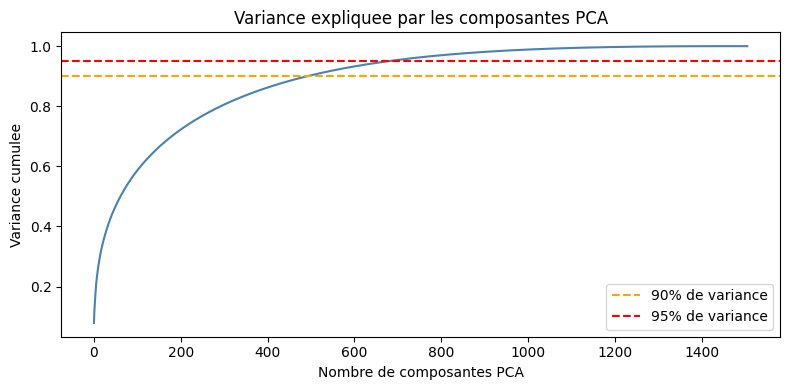

Composantes necessaires pour 90% de variance : 493
Composantes necessaires pour 95% de variance : 679


In [7]:
# Courbe de variance cumulee -- montre combien de composantes sont necessaires
# pour conserver X% de l'information
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(features_scaled)
variance_cumulative = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(variance_cumulative, color="steelblue")
plt.axhline(y=0.90, color="orange", linestyle="--", label="90% de variance")
plt.axhline(y=0.95, color="red",    linestyle="--", label="95% de variance")
plt.xlabel("Nombre de composantes PCA")
plt.ylabel("Variance cumulee")
plt.title("Variance expliquee par les composantes PCA")
plt.legend()
plt.tight_layout()
plt.show()

# Affiche combien de composantes sont necessaires pour 90% et 95% de variance
n_90 = np.argmax(variance_cumulative >= 0.90) + 1
n_95 = np.argmax(variance_cumulative >= 0.95) + 1
print(f"Composantes necessaires pour 90% de variance : {n_90}")
print(f"Composantes necessaires pour 95% de variance : {n_95}")

### Etape 2 : Reduction a 2D pour visualisation

On applique les 3 methodes (PCA, UMAP, t-SNE) pour comparer leurs visualisations.

In [8]:
# --- PCA 2D ---
# Reduction lineaire directe de 2048 a 2 dimensions
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
features_pca2d = pca_2d.fit_transform(features_scaled)
print(f"PCA 2D OK -- shape : {features_pca2d.shape}")

PCA 2D OK -- shape : (1506, 2)


In [9]:
# --- UMAP 2D ---
# Reduction non-lineaire : part des 150 dimensions PCA pour aller plus vite
# n_neighbors : nombre de voisins consideres -- valeur plus grande = structure globale mieux preservee
# min_dist    : distance minimale entre points en 2D -- valeur faible = clusters plus compacts
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_STATE
)
features_umap = umap_model.fit_transform(features_pca150)
print(f"UMAP 2D OK -- shape : {features_umap.shape}")

c:\Users\fkhellad\Formation_IA\Projet7_mission\.venv\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP 2D OK -- shape : (1506, 2)


In [10]:
# --- t-SNE 2D (pour comparaison) ---
# Reduction non-lineaire : part aussi des 150 dimensions PCA
# perplexity : nombre de voisins effectifs consideres -- typiquement entre 5 et 50
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE,
    n_iter=1000
)
features_tsne = tsne_model.fit_transform(features_pca150)
print(f"t-SNE 2D OK -- shape : {features_tsne.shape}")

c:\Users\fkhellad\Formation_IA\Projet7_mission\.venv\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE 2D OK -- shape : (1506, 2)


## 6. Visualisation des reductions (couleur = vrai label)

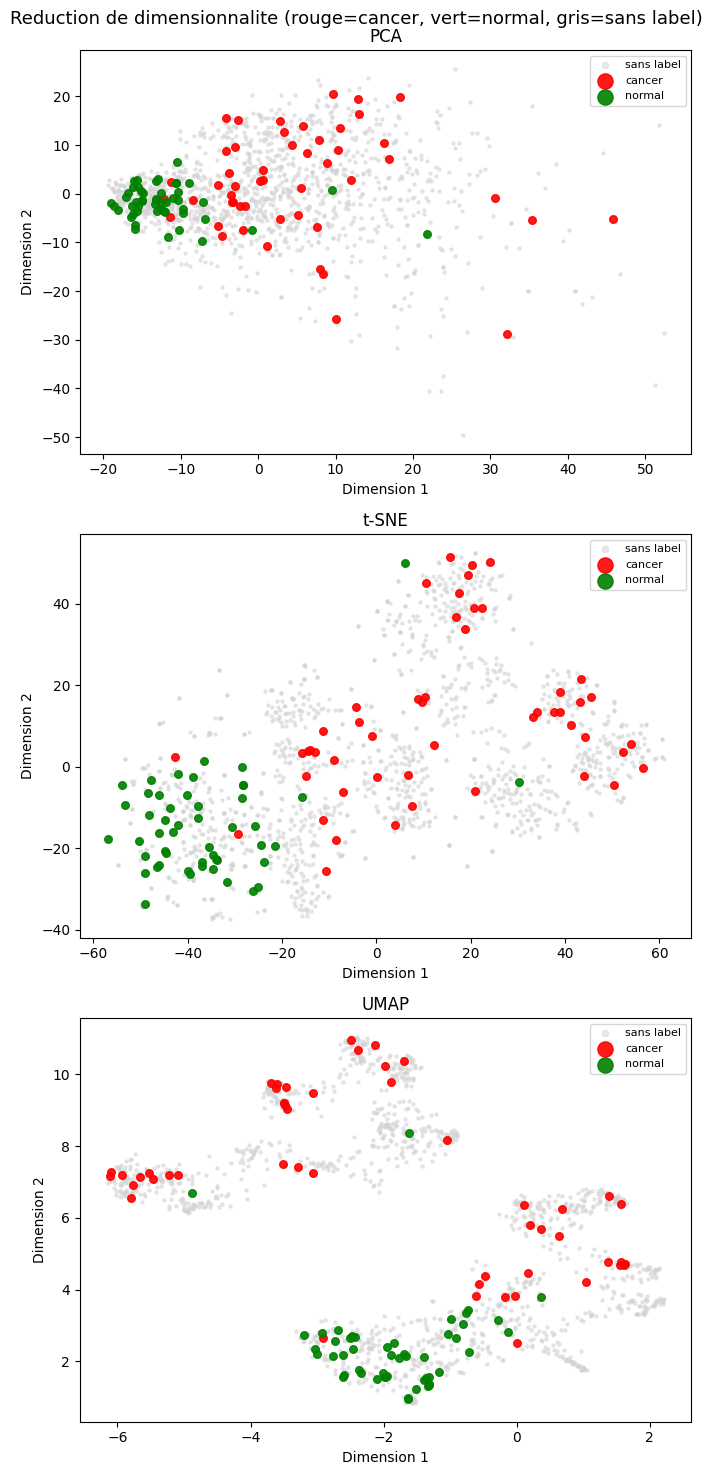

Graphique sauvegarde dans results/


In [11]:
# Créer un tableau de couleurs pour chaque image
# Les 100 images labelisées sont colorees (rouge/vert), les sans-label en gris
def make_colors(meta):
    """Retourne une liste de couleurs et labels pour chaque image."""
    colors = []
    for _, row in meta.iterrows():
        if row["label"] == "cancer":
            colors.append("red")
        elif row["label"] == "normal":
            colors.append("green")
        else:
            colors.append("lightgray")  # Images sans label
    return colors

colors = make_colors(meta)

fig, axes = plt.subplots(3, 1, figsize=(7, 15))
fig.suptitle("Reduction de dimensionnalite (rouge=cancer, vert=normal, gris=sans label)", fontsize=13)

# Affiche les sans-label en premier (arriere-plan), puis les labels par-dessus
for ax, data, title in zip(
    axes,
    [features_pca2d, features_tsne, features_umap],
    ["PCA", "t-SNE", "UMAP"]
):
    # Points sans label en gris (en arriere-plan)
    ax.scatter(
        data[unlabeled_mask, 0], data[unlabeled_mask, 1],
        c="lightgray", s=5, alpha=0.5, label="sans label"
    )
    # Points cancer en rouge
    cancer_mask = meta["label"] == "cancer"
    ax.scatter(
        data[cancer_mask, 0], data[cancer_mask, 1],
        c="red", s=30, alpha=0.9, label="cancer"
    )
    # Points normal en vert
    normal_mask = meta["label"] == "normal"
    ax.scatter(
        data[normal_mask, 0], data[normal_mask, 1],
        c="green", s=30, alpha=0.9, label="normal"
    )
    ax.set_title(title, fontsize=12)
    ax.legend(markerscale=2, fontsize=8)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dimensionality_reduction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegarde dans results/")

## 7. Clustering K-Means

K-Means cherche K=2 centres (cancer et normal) en minimisant la distance entre chaque point et son centre.  
On l'applique sur les **2 dimensions UMAP** -- même espace que DBSCAN pour une comparaison équitable.

In [12]:
# n_init=10 : lance l'algorithme 10 fois avec des centres differents et garde le meilleur resultat
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    n_init=10,
    random_state=RANDOM_STATE
)

# Entrainer K-Means sur les 2 dimensions UMAP -- meme espace que DBSCAN
labels_kmeans = kmeans.fit_predict(features_umap)

# Compte le nombre d'images par cluster
unique, counts = np.unique(labels_kmeans, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster} : {count} images")

# Score de silhouette : mesure la coherence interne des clusters
# Valeur entre -1 et 1 -- plus c'est proche de 1, plus les clusters sont bien separes
sil_kmeans = silhouette_score(
    features_umap,
    labels_kmeans,
    random_state=RANDOM_STATE
)
print(f"\nScore de silhouette K-Means : {sil_kmeans:.4f}")

  Cluster 0 : 663 images
  Cluster 1 : 843 images

Score de silhouette K-Means : 0.5641


## 8. Clustering DBSCAN

DBSCAN detecte des zones denses sans fixer K a l'avance.  
- **eps** : rayon de recherche -- si deux points sont a moins de eps, ils sont voisins  
- **min_samples** : nombre minimum de voisins pour qu'un point soit considere comme coeur d'un cluster  
- Les points isoles (pas assez de voisins) sont marques **-1** (bruit)

In [13]:
# DBSCAN sur les 2 dimensions UMAP -- plus interpretable visuellement
# eps et min_samples sont des hyperparametres a ajuster selon les resultats
dbscan = DBSCAN(
    eps=0.3,          # Rayon de voisinage
    min_samples=5     # Minimum de voisins pour former un cluster
)

labels_dbscan = dbscan.fit_predict(features_umap)

# Analyse des clusters trouves
unique_dbscan, counts_dbscan = np.unique(labels_dbscan, return_counts=True)
n_clusters_dbscan = len(unique_dbscan[unique_dbscan != -1])  # Exclut le bruit (-1)
n_noise          = np.sum(labels_dbscan == -1)

print(f"Clusters trouves par DBSCAN : {n_clusters_dbscan}")
print(f"Points consideres comme bruit (-1) : {n_noise}")
for cluster, count in zip(unique_dbscan, counts_dbscan):
    label = "bruit" if cluster == -1 else f"Cluster {cluster}"
    print(f"  {label} : {count} images")

Clusters trouves par DBSCAN : 5
Points consideres comme bruit (-1) : 9
  bruit : 9 images
  Cluster 0 : 199 images
  Cluster 1 : 661 images
  Cluster 2 : 178 images
  Cluster 3 : 221 images
  Cluster 4 : 238 images


## 9. Visualisation des clusters

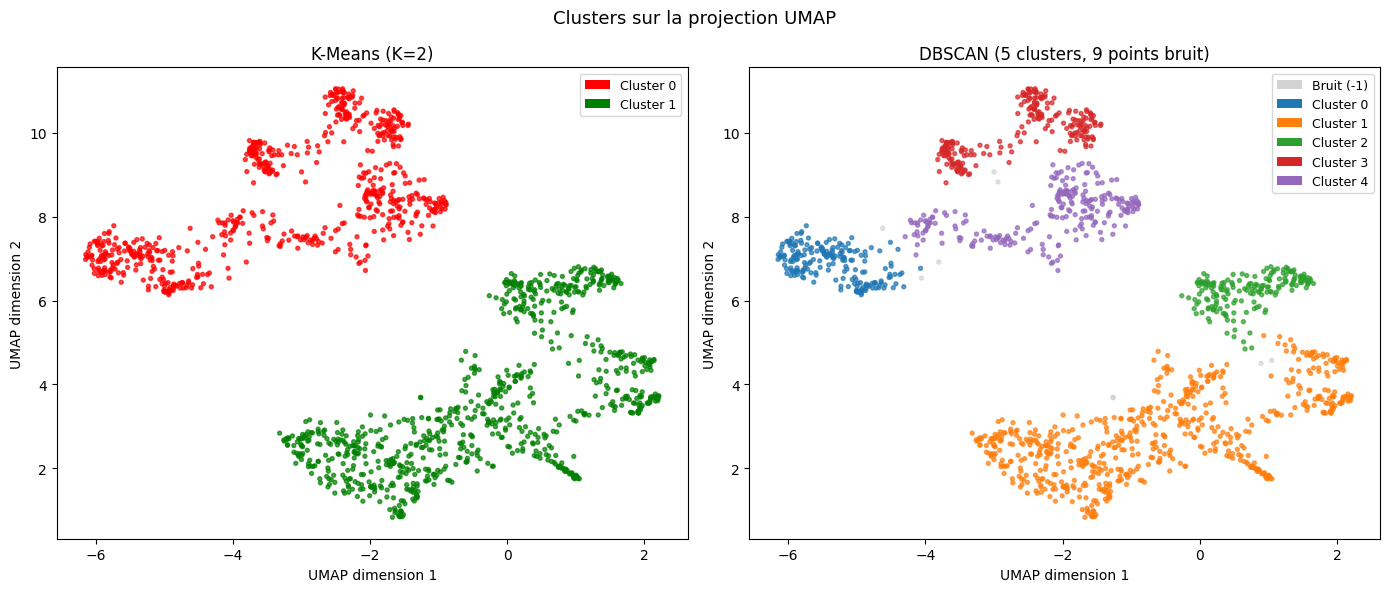

In [14]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Clusters sur la projection UMAP", fontsize=13)

# ------- K-Means sur UMAP -------
colors_kmeans = ["red" if l == 0 else "green" for l in labels_kmeans]

axes[0].scatter(features_umap[:, 0], features_umap[:, 1], c=colors_kmeans, s=8, alpha=0.7)
axes[0].set_title(f"K-Means (K={N_CLUSTERS})")
axes[0].set_xlabel("UMAP dimension 1")
axes[0].set_ylabel("UMAP dimension 2")

legend_km = [Patch(facecolor="red",   label="Cluster 0"),
             Patch(facecolor="green", label="Cluster 1")]

axes[0].legend(handles=legend_km, fontsize=9)




# ------- DBSCAN sur UMAP -------
palette = ["lightgray"] + sns.color_palette("tab10", n_colors=max(labels_dbscan) + 1).as_hex()
colors_dbscan = [palette[l + 1] for l in labels_dbscan]

axes[1].scatter(features_umap[:, 0], features_umap[:, 1], c=colors_dbscan, s=8, alpha=0.7)
axes[1].set_title(f"DBSCAN ({n_clusters_dbscan} clusters, {n_noise} points bruit)")
axes[1].set_xlabel("UMAP dimension 1")
axes[1].set_ylabel("UMAP dimension 2")

legend_db = [Patch(facecolor="lightgray", label="Bruit (-1)")]
legend_db += [Patch(facecolor=palette[i + 1], label=f"Cluster {i}")
              for i in range(n_clusters_dbscan)]

axes[1].legend(handles=legend_db, fontsize=9)



plt.tight_layout()
plt.savefig(RESULTS_DIR / "clustering_results.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Evaluation avec le score ARI

Evaluation de la qualite du clustering   
Les vrais labels (cancer=1, normal=0) sont compares aux clusters trouves par les algorithmes.  

In [15]:
# Convertit les vrais labels en 0/1 pour le calcul de l'ARI
# 1 = cancer, 0 = normal
# Uniquement sur les 80 images d'entrainement labelisees -- les 20 de test sont exclues
true_labels = (meta_labeled["label"] == "cancer").astype(int).values

# Extrait les labels de cluster pour les 80 images train labelisees uniquement
kmeans_labels_labeled = labels_kmeans[train_labeled_mask]
dbscan_labels_labeled = labels_dbscan[train_labeled_mask]

# Calcul du score ARI
# L'ARI est insensible a la permutation des labels (cluster 0 <-> cluster 1 n'a pas d'importance)
ari_kmeans = adjusted_rand_score(true_labels, kmeans_labels_labeled)
ari_dbscan = adjusted_rand_score(true_labels, dbscan_labels_labeled)

print("Score ARI (sur les 80 images train labelisees) :")
print(f"  K-Means  : {ari_kmeans:.4f}")
print(f"  DBSCAN   : {ari_dbscan:.4f}")
print()
print("Interpretation :")
print("  ARI > 0.5  : bon clustering")
print("  ARI 0.1-0.5 : clustering partiel")
print("  ARI < 0.1  : proche du hasard")

Score ARI (sur les 80 images train labelisees) :
  K-Means  : 0.2947
  DBSCAN   : 0.3064

Interpretation :
  ARI > 0.5  : bon clustering
  ARI 0.1-0.5 : clustering partiel
  ARI < 0.1  : proche du hasard


## 11. Attribution des labels faibles aux images sans label

In [16]:
# determiner quelle cluster K-Means correspond a cancer et lequel a normal
# en comparant avec les vrais labels des 100 images fortement labelisees
cluster_0_cancer = np.mean(true_labels[kmeans_labels_labeled == 0])
cluster_1_cancer = np.mean(true_labels[kmeans_labels_labeled == 1])

# Le cluster avec la plus grande proportion de cancer est le cluster "cancer"
cancer_cluster = 0 if cluster_0_cancer > cluster_1_cancer else 1
normal_cluster = 1 - cancer_cluster

print(f"Cluster {cancer_cluster} -> label faible : cancer")
print(f"Cluster {normal_cluster} -> label faible : normal")

# Applique les labels faibles a tout le dataset
weak_labels = np.where(labels_kmeans == cancer_cluster, "cancer", "normal")

# Ajoute les labels faibles au DataFrame de metadonnees
meta["weak_label"] = weak_labels
meta["cluster_kmeans"] = labels_kmeans

print(f"\nDistribution des labels faibles (tout le dataset) :")
print(meta["weak_label"].value_counts())

Cluster 0 -> label faible : cancer
Cluster 1 -> label faible : normal

Distribution des labels faibles (tout le dataset) :
weak_label
normal    843
cancer    663
Name: count, dtype: int64


### Attribution des labels faibles avec DBSCAN

Pour chaque cluster DBSCAN, la proportion de vraies images cancer parmi les images labelisées détermine le label attribué.  
Les 9 points bruit (-1) sont classés **cancer** : dans un contexte médical, un faux positif est préférable à un faux négatif.

In [17]:
# Déterminer le label de chaque cluster DBSCAN par vote majoritaire
# sur les images d'entraînement labelisées
dbscan_cluster_map = {}
for cluster_id in np.unique(labels_dbscan):
    if cluster_id == -1:
        continue
    in_cluster_labeled = (labels_dbscan == cluster_id) & train_labeled_mask
    if in_cluster_labeled.sum() == 0:
        dbscan_cluster_map[cluster_id] = "normal"  # Défaut si aucun label connu dans ce cluster
    else:
        prop_cancer = (meta[in_cluster_labeled]["label"] == "cancer").mean()
        dbscan_cluster_map[cluster_id] = "cancer" if prop_cancer > 0.5 else "normal"

print("Correspondance clusters DBSCAN -> label faible :")
for cluster_id, label in dbscan_cluster_map.items():
    print(f"  Cluster {cluster_id} -> {label}")

# Attribuer les labels faibles DBSCAN à toutes les images
# Points bruit (-1) -> cancer (préférable au faux négatif en médical)
weak_labels_dbscan = np.array([
    "cancer" if l == -1 else dbscan_cluster_map[l]
    for l in labels_dbscan
])

meta["weak_label_dbscan"] = weak_labels_dbscan
meta["cluster_dbscan"]    = labels_dbscan

print(f"\nDistribution des labels faibles DBSCAN :")
print(meta["weak_label_dbscan"].value_counts())

Correspondance clusters DBSCAN -> label faible :
  Cluster 0 -> cancer
  Cluster 1 -> normal
  Cluster 2 -> cancer
  Cluster 3 -> cancer
  Cluster 4 -> cancer

Distribution des labels faibles DBSCAN :
weak_label_dbscan
cancer    845
normal    661
Name: count, dtype: int64


## 12. Tableau de comparaison des methodes

In [18]:
# Resume des resultats pour faciliter la comparaison
resultats = pd.DataFrame({
    "Methode"          : ["K-Means", "DBSCAN"],
    "Nb clusters"      : [N_CLUSTERS, n_clusters_dbscan],
    "Points bruit"     : [0, n_noise],
    "ARI"              : [round(ari_kmeans, 4), round(ari_dbscan, 4)],
    "Silhouette"       : [round(sil_kmeans, 4), "N/A"],
})
print(resultats.to_string(index=False))

# Tableau de comparaison des algorithmes de clustering
resultats.to_csv(PROCESSED_DIR / "clustering_comparison.csv", index=False)

# Métadonnées avec labels faibles DBSCAN uniquement -- utilisé à l'étape 4
meta_dbscan = meta[["path", "label", "split", "weak_label_dbscan", "cluster_dbscan"]].copy()
meta_dbscan.to_csv(PROCESSED_DIR / "metadata_weak_labels_dbscan.csv", index=False)

print("\nFichiers sauvegardés dans data/processed/ :")
print(f"  clustering_comparison.csv         -- comparaison K-Means vs DBSCAN")
print(f"  metadata_weak_labels_dbscan.csv   -- {len(meta_dbscan)} images avec labels DBSCAN")

Methode  Nb clusters  Points bruit    ARI Silhouette
K-Means            2             0 0.2947     0.5641
 DBSCAN            5             9 0.3064        N/A

Fichiers sauvegardés dans data/processed/ :
  clustering_comparison.csv         -- comparaison K-Means vs DBSCAN
  metadata_weak_labels_dbscan.csv   -- 1506 images avec labels DBSCAN


## 12b. Analyse des biais — déséquilibre des classes

Les images labelisées (cancer/normal) sont parfaitement équilibrées (50/50). Cependant, les **weak labels générés par DBSCAN** peuvent introduire un déséquilibre sur les 1486 images d'entraînement.

On analyse ici ce déséquilibre potentiel et on détermine si un rééquilibrage est nécessaire.

Vrais labels — 80 images train labelisées :
label
cancer    40
normal    40
Name: count, dtype: int64
  → Ratio cancer : 50.0%  (parfaitement équilibré)

Weak labels DBSCAN — 1486 images train :
weak_label_dbscan
cancer    839
normal    647
Name: count, dtype: int64
  → Ratio cancer : 56.5% | Ratio normal : 43.5%


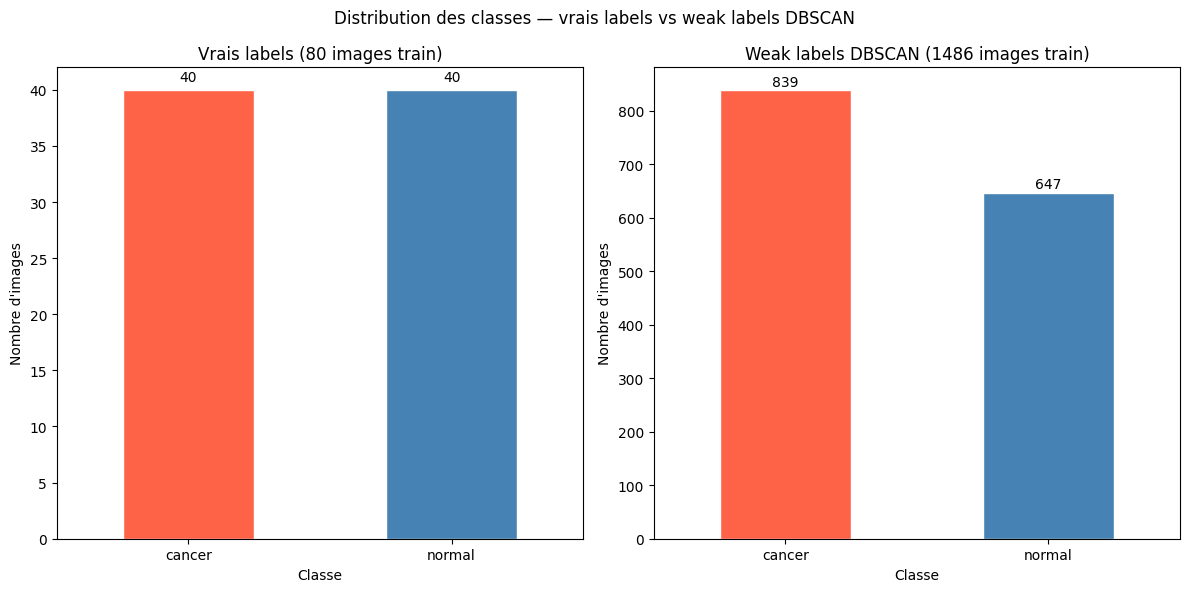


Déséquilibre DBSCAN : 6.5% d'écart par rapport à 50/50
→ Déséquilibre faible — pas de rééquilibrage appliqué.
  Le F2-score (β=2) utilisé à l'étape 4 compense ce biais en pénalisant
  davantage les faux négatifs (cancers manqués) que les faux positifs.


In [22]:
meta_train_only = meta[~meta["path"].isin(test_paths_set)].reset_index(drop=True)

# ── Vrais labels : 80 images fortement labelisées ────────────────────────────
labels_forts = meta_train_only[meta_train_only["label"].notna()]["label"]
print("Vrais labels — 80 images train labelisées :")
print(labels_forts.value_counts())
print(f"  → Ratio cancer : {labels_forts.value_counts(normalize=True)['cancer']:.1%}  (parfaitement équilibré)")

# ── Weak labels DBSCAN : 1486 images train ───────────────────────────────────
dist_weak  = meta_train_only["weak_label_dbscan"].value_counts()
ratio_weak = meta_train_only["weak_label_dbscan"].value_counts(normalize=True)

print(f"\nWeak labels DBSCAN — {len(meta_train_only)} images train :")
print(dist_weak)
print(f"  → Ratio cancer : {ratio_weak['cancer']:.1%} | Ratio normal : {ratio_weak['normal']:.1%}")

# ── Visualisation comparative ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Distribution des classes — vrais labels vs weak labels DBSCAN", fontsize=12)

labels_forts.value_counts().plot(kind="bar", ax=axes[0], color=["tomato", "steelblue"], edgecolor="white")
axes[0].set_title("Vrais labels (80 images train)")
axes[0].set_xlabel("Classe"); axes[0].set_ylabel("Nombre d'images")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

dist_weak.plot(kind="bar", ax=axes[1], color=["tomato", "steelblue"], edgecolor="white")
axes[1].set_title("Weak labels DBSCAN (1486 images train)")
axes[1].set_xlabel("Classe"); axes[1].set_ylabel("Nombre d'images")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# ── Décision de rééquilibrage ─────────────────────────────────────────────────
desequilibre = abs(ratio_weak["cancer"] - 0.5)
print(f"\nDéséquilibre DBSCAN : {desequilibre:.1%} d'écart par rapport à 50/50")
print("→ Déséquilibre faible — pas de rééquilibrage appliqué.")
print("  Le F2-score (β=2) utilisé à l'étape 4 compense ce biais en pénalisant")
print("  davantage les faux négatifs (cancers manqués) que les faux positifs.")

## 13. Visualisation finale -- vrais labels vs clusters K-Means

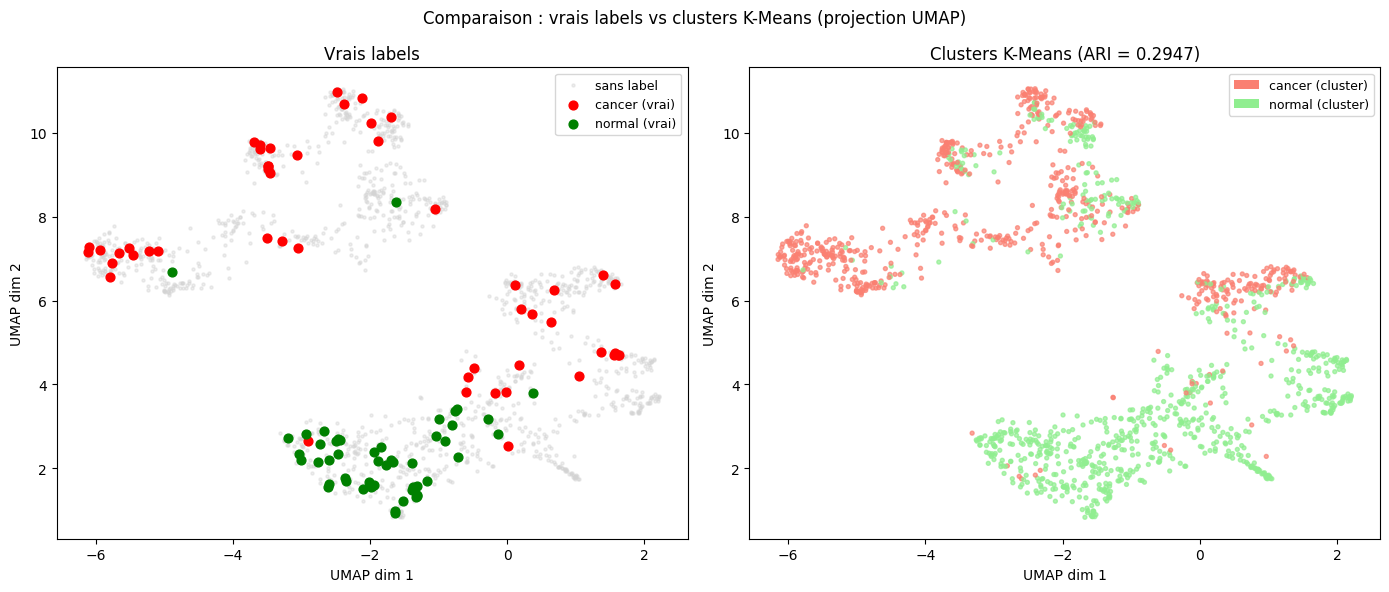

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparaison : vrais labels vs clusters K-Means (projection UMAP)", fontsize=12)

# --- Vrais labels (fortement labellises seulement) ---
axes[0].scatter(
    features_umap[unlabeled_mask, 0], features_umap[unlabeled_mask, 1],
    c="lightgray", s=5, alpha=0.4, label="sans label"
)
axes[0].scatter(
    features_umap[meta["label"] == "cancer", 0],
    features_umap[meta["label"] == "cancer", 1],
    c="red", s=40, label="cancer (vrai)"
)
axes[0].scatter(
    features_umap[meta["label"] == "normal", 0],
    features_umap[meta["label"] == "normal", 1],
    c="green", s=40, label="normal (vrai)"
)
axes[0].set_title("Vrais labels")
axes[0].legend(fontsize=9)
axes[0].set_xlabel("UMAP dim 1")
axes[0].set_ylabel("UMAP dim 2")

# --- Clusters K-Means ---
axes[1].scatter(
    features_umap[:, 0], features_umap[:, 1],
    c=["salmon" if l == cancer_cluster else "lightgreen" for l in labels_kmeans],
    s=8, alpha=0.7
)
axes[1].set_title(f"Clusters K-Means (ARI = {ari_kmeans:.4f})")
axes[1].set_xlabel("UMAP dim 1")
axes[1].set_ylabel("UMAP dim 2")

# Legende manuelle
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="salmon", label="cancer (cluster)"),
                   Patch(facecolor="lightgreen", label="normal (cluster)")]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "true_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Visualisation finale -- vrais labels vs clusters DBSCAN

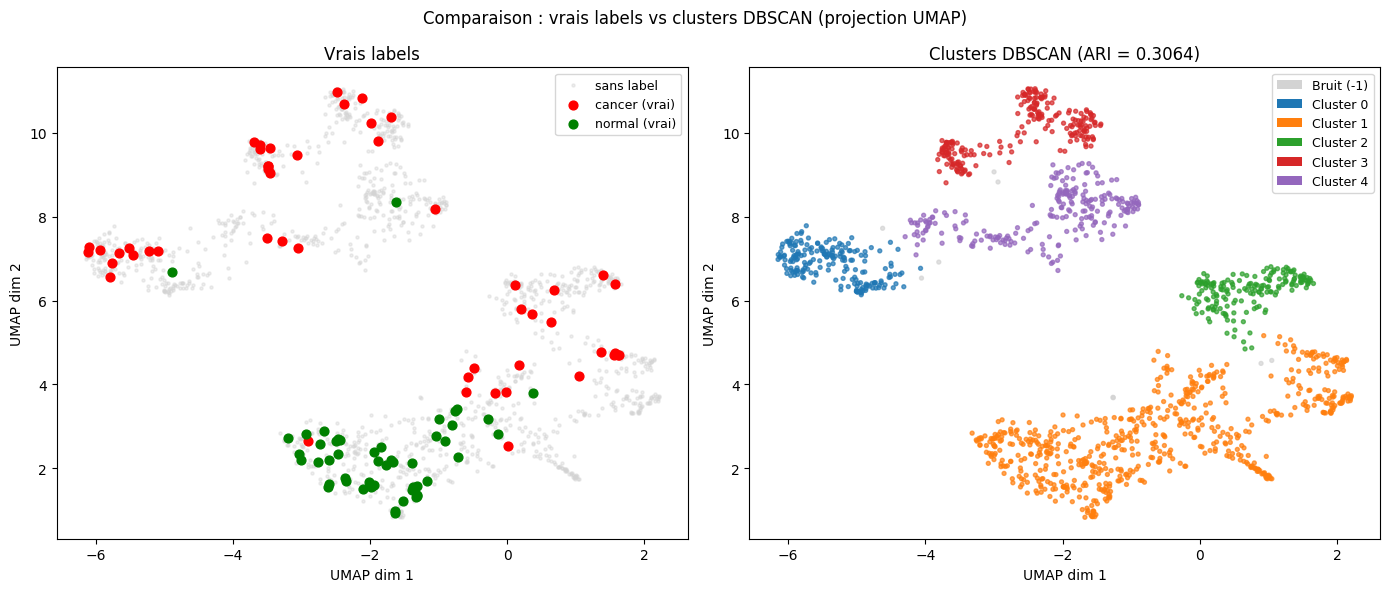

In [32]:
# Comparaison vrais labels vs clusters DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparaison : vrais labels vs clusters DBSCAN (projection UMAP)", fontsize=12)

# --- Vrais labels ---
axes[0].scatter(
    features_umap[unlabeled_mask, 0], features_umap[unlabeled_mask, 1],
    c="lightgray", s=5, alpha=0.4, label="sans label"
)
axes[0].scatter(
    features_umap[meta["label"] == "cancer", 0],
    features_umap[meta["label"] == "cancer", 1],
    c="red", s=40, label="cancer (vrai)"
)
axes[0].scatter(
    features_umap[meta["label"] == "normal", 0],
    features_umap[meta["label"] == "normal", 1],
    c="green", s=40, label="normal (vrai)"
)
axes[0].set_title("Vrais labels")
axes[0].legend(fontsize=9)
axes[0].set_xlabel("UMAP dim 1")
axes[0].set_ylabel("UMAP dim 2")

# --- Clusters DBSCAN ---
palette_db = {-1: "lightgray"}
palette_db.update({i: c for i, c in enumerate(
    sns.color_palette("tab10", n_colors=n_clusters_dbscan).as_hex()
)})
colors_dbscan = [palette_db[l] for l in labels_dbscan]
axes[1].scatter(
    features_umap[:, 0], features_umap[:, 1],
    c=colors_dbscan, s=8, alpha=0.7
)
axes[1].set_title(f"Clusters DBSCAN (ARI = {ari_dbscan:.4f})")
axes[1].set_xlabel("UMAP dim 1")
axes[1].set_ylabel("UMAP dim 2")

# Legende : bruit en premier, puis un Patch par cluster
legend_db = [Patch(facecolor="lightgray", label="Bruit (-1)")]
legend_db += [Patch(facecolor=palette_db[i], label=f"Cluster {i}")
              for i in range(n_clusters_dbscan)]
axes[1].legend(handles=legend_db, fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "true_vs_predicted_dbscan.png", dpi=150, bbox_inches="tight")
plt.show()


## 15. Conclusions

### Process suivi

1. **Chargement** : matrice de features ResNet50 (1506 x 2048) produite dans preprocessing_feature_extraction.ipynb
2. **Separation test** : 20 images mises de cote des le debut (10 cancer + 10 normal, stratifie) -- jamais utilisees dans ce notebook
3. **Standardisation** : StandardScaler entraine sur 1486 images (hors test set) pour eviter tout leakage
4. **Reduction PCA** : 2048 -> 150 dimensions (66.25% de variance expliquee) -- pre-reduction pour accelerer UMAP
5. **Visualisation 2D** : PCA, t-SNE et UMAP pour projeter les donnees en 2 dimensions
6. **Clustering** : K-Means (K=2) et DBSCAN (eps=0.3) -- tous deux appliques sur UMAP 2D pour comparaison equitable
7. **Evaluation ARI** : scores calcules sur les 80 images train labelisees uniquement
8. **Labels faibles DBSCAN** : attribues a toutes les 1506 images -- sauvegardes dans `metadata_weak_labels_dbscan.csv`

### Resultats

| Methode | Clusters | Bruit | ARI    | Silhouette |
|---------|----------|-------|--------|------------|
| K-Means | 2        | 0     | 0.2947 | 0.5641     |
| DBSCAN  | 5        | 9     | 0.3064 |   --       |

- **Labels faibles retenus** : DBSCAN (ARI = 0.3064, structure plus naturelle des donnees)
- **Points bruit DBSCAN** : 9 images classees cancer par precaution (faux positif < faux negatif en detection cancer)
- **Fichiers produits pour l'etape 4** : `metadata_weak_labels_dbscan.csv`, `test_set.csv`